In [1]:
import sys
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import subprocess
import os
import cell2location
import scvi
from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42  # enables correct plotting of text
import seaborn as sns
from cell2location.utils.filtering import filter_genes

/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
# spatial_file_path = sys.argv[2]
# sc_file_path = sys.argv[1]
# celltype_key = sys.argv[3]
# output_file_path = sys.argv[4]
# sample_name = sys.argv[5]
# sample_name = sample_name.split('.h5a')[0]
# sce = sys.argv[6]
spatial_file_path = "/home/jxliu/Desktop/projects/staid/data/simulation/Puck-191204-01_100_simulated.h5ad"
sc_file_path = "/home/jxliu/Desktop/projects/staid/data/simulation/scRNA_Hippocampus_191204-01_s1.h5ad"
celltype_key = 'cell_type'
output_file_path = '/home/jxliu/Desktop/projects/staid/results/simulation/s1'
sample_name = 'Puck-191204-01_100_simulated.h5ad'
sample_name = sample_name.split('.h5a')[0]
sce = 's1'


In [3]:
file_name = 'cell2location_' + \
            sample_name + "_" + sce + "_results.csv"
res_file_path = os.path.join(output_file_path, file_name)
print(res_file_path)
print(sc_file_path)
print(celltype_key)
adata_snrna_raw = sc.read_h5ad(sc_file_path)
adata_vis = sc.read_h5ad(spatial_file_path)
adata_snrna_raw.var_names_make_unique()
adata_vis.var_names_make_unique()

/home/jxliu/Desktop/projects/staid/results/simulation/s1/cell2location_Puck-191204-01_100_simulated_s1_results.csv
/home/jxliu/Desktop/projects/staid/data/simulation/scRNA_Hippocampus_191204-01_s1.h5ad
cell_type


In [4]:

sc.pp.filter_genes(adata_snrna_raw, min_cells=1)
sc.pp.filter_cells(adata_snrna_raw, min_genes=1)

/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [5]:
adata_snrna_raw.obs

,cluster,subcluster,cell_type,batch,n_genes
P60HippoRep3P3_TGTCCGGAAGCN,11.0,11-1,Ependyma,0,2259
P60HippoRep2P1_GACGTGATGAAG,11.0,11-1,Ependyma,0,2197
P60HippoRep4P3_ATATATAACTGG,11.0,11,Ependyma,0,659
P60HippoRep5P2_ATCAGGATTTTG,11.0,11,Ependyma,0,475
P60HippoRep4P3_TCCTCCGGAGAA,11.0,11-1,Ependyma,0,1280
...,...,...,...,...,...
P60HippoRep4P1_CGATTTTGACAT,10.0,10,Microglia_Macrophage_C1qb,1,573
P60HippoRep4P1_AATAGCAGTTGC,10.0,10,Microglia_Macrophage_C1qb,1,433
P60HippoRep4P1_ATATGGTTTACC,10.0,10,Microglia_Macrophage_C1qb,1,408
P60HippoRep2P1_ATGCCCAGAGTT,10.0,10-1,Microglia_Macrophage_C1qb,1,657


/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/cell2location/utils/filtering.py:26: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = np.array((adata.X > 0).sum(0)).flatten()
/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


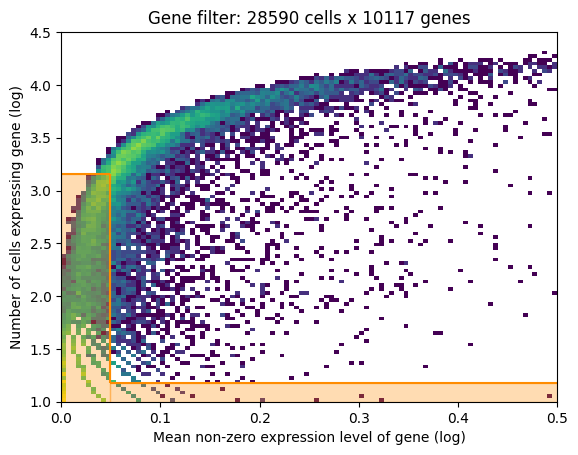

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [6]:
adata_snrna_raw.obs[celltype_key] = pd.Categorical(adata_snrna_raw.obs[celltype_key])
adata_snrna_raw = adata_snrna_raw[~adata_snrna_raw.obs[celltype_key].isna(), :]
selected = filter_genes(adata_snrna_raw)
# filter the object
adata_snrna_raw = adata_snrna_raw[:, selected].copy()
cell2location.models.RegressionModel.setup_anndata(adata=adata_snrna_raw,
                                                   labels_key=celltype_key)

In [7]:
from cell2location.models import RegressionModel

mod = RegressionModel(adata_snrna_raw)

In [ ]:
mod.train(use_gpu=True)
plt.close('all')

/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/scvi/train/_trainrunner.py:76: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jxliu/anaconda3/envs/cell2loc_env/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, r

Epoch 86/700:  12%|█████                                     | 85/700 [03:25<26:20,  2.57s/it, v_num=1, elbo_train=1.19e+8]